In [22]:
import numpy as np
import matplotlib.pyplot as plt
dsep = 0.5  # Antenna separation in wavelengths
snr0_dB = 10  # Initial SNR0 in dB
snr1_dB = 10  # Initial SNR1 in dB
sigma_N0 = 10**(-0.1 * snr0_dB)
sigma_N1 = 10**(-0.1 * snr1_dB)

nsamp = 100  # Number of samples
t = np.arange(nsamp)
X = np.exp(1j * 2 * np.pi * 0.1*t) # reference signal
E_r = np.linalg.norm(X)**2
E_t = np.linalg.norm(X)**2/nsamp

theta0 = 0  # Angle to RX0
theta1 = 15
theta0_rad = theta0 * np.pi / 180
theta1_rad = theta1 * np.pi / 180
num = 1

ntx_num = np.array([  16*num,32*num,48*num,64*num])
ntx_len = len(ntx_num)
nt = 50 # tota; runing times
gamma_num = 500
gamma_h1 = np.logspace(-4, 8, gamma_num) # adjustment to h1



inr = np.zeros((ntx_len,nt,gamma_num  ))
G_i = np.zeros((ntx_len,nt,gamma_num  ))
INR_theory_correct = np.zeros((ntx_len,nt,gamma_num  ))
INR_theory_incorrect = np.zeros((ntx_len,nt,gamma_num  ))
INR_new = np.zeros((ntx_len,nt,gamma_num  ))
INR_pow= np.zeros((ntx_len,nt,gamma_num  ))
INR0_pow= np.zeros((ntx_len,nt,gamma_num  ))
INR2_pow= np.zeros((ntx_len,nt,gamma_num  ))
INR3_pow= np.zeros((ntx_len,nt,gamma_num  ))
INR4_pow= np.zeros((ntx_len,nt,gamma_num  ))
rho_hat_list = np.zeros((ntx_len,nt,gamma_num  ))
rho_nom_abs2_list= np.zeros((ntx_len,nt,gamma_num  ))



In [23]:
def beamforming_vec(h0, h1):

    C0 = np.linalg.norm(h0)**2
    C1 = np.linalg.norm(h1)**2
    # rho = np.conj(h0.T) @ h1 / np.sqrt(C1 * C0)
    rho = np.conj(h1.T) @ h0 / np.sqrt(C1 * C0)
    alpha0 = 1 / (np.sqrt(1 - np.abs(rho)**2) * np.sqrt(C0))
    alpha1 = -rho / (np.sqrt(1 - np.abs(rho)**2) * np.sqrt(C1))
    w = alpha0 * h0 + alpha1 * h1

    return w, rho

for ntxn, ntx in enumerate(ntx_num):

    phase0 = 2 * np.pi * np.arange(ntx) * dsep * np.cos(theta0_rad)
    phase1 = 2 * np.pi * np.arange(ntx) * dsep * np.cos(theta1_rad)
    h0 = np.exp(1j * phase0).reshape(-1,1)
    h1 = np.exp(1j * phase1).reshape(-1,1)

    for g, gamma in enumerate(gamma_h1):


        for n in range (nt):

            G_i[ntxn,n,g] = np.linalg.norm(gamma*h1)**2  /ntx
            G_0 = np.linalg.norm(h0)**2  /ntx
                         # gamma_r^i in paper
            N = (np.random.randn(ntx, nsamp) + 1j * np.random.randn(ntx, nsamp)) * np.sqrt(sigma_N1 / 2)  #
            N0 = np.mean(np.abs(N)**2)
            # N0_total = np.abs(N)**2
            snr_1_r = E_r*G_i[ntxn,n,g]/N0
            
            
            Y_i = gamma*h1 @ X.reshape(1, nsamp) + N  #
            h1_est = (np.sum(Y_i * (np.conj(X) / (np.abs(X) ** 2)), axis=1) / nsamp).reshape(-1,1)


            h1_hat = ((h1_est)*np.sqrt(ntx)  /np.linalg.norm(h1_est)).reshape(-1,1) # normalized h1_est to sqrt|ntx|
            
            V = h1_hat - h1

            [w_t,rho_hat] = beamforming_vec(h0, h1_hat)
            
            
            

            
            
            h1_ = ((gamma*h1)*np.sqrt(ntx)  /np.linalg.norm(gamma*h1)).reshape(-1,1) # real h1 after normalized to sqrt|ntx|
            [w_real,rho] = beamforming_vec(h0, h1_)  # real rho
            
            
            rho_nom_abs2 = np.abs(rho)**2   
            rho_hat_nom_abs2 = np.abs(rho_hat)**2 
            
            rho_hat_list[ntxn,n,g] = np.linalg.norm(rho_hat)**2
            rho_nom_abs2_list[ntxn,n,g] = np.linalg.norm(rho)**2
            
            # the real inr
            inr[ntxn,n,g] = np.abs(np.conj(w_t.T) @ (gamma*h1))**2 / N0    
            
                 
            # the inr with 1-rho in equ(21), which matches the real inr
            INR_theory_incorrect[ntxn,n,g] = (E_t/E_r) * (snr_1_r / ((1+snr_1_r)*(1+snr_1_r - snr_1_r * rho_nom_abs2))) * \
                             (rho_nom_abs2 * ntx + snr_1_r * (1 - rho_nom_abs2))
                             
            # the inr with 1+rho in equ(20), which matches the formula                 
            INR_theory_correct[ntxn,n,g] = (E_t/E_r) * (snr_1_r / ((1+snr_1_r)*(1+snr_1_r - snr_1_r * rho_nom_abs2))) * \
                             (rho_nom_abs2 * ntx + snr_1_r * (1 + rho_nom_abs2))
                             
                             
            INR_new[ntxn,n,g] = (E_t/E_r) * (snr_1_r / ((1+snr_1_r)*(1+snr_1_r - snr_1_r * rho_nom_abs2))) * \
                                    (rho_nom_abs2 * ntx + (1 + rho_nom_abs2)/snr_1_r )
                             
            # the inr from S(D^2+E(V)^2),as equ (54-a)                  
            S = (1+snr_1_r)/ntx/G_0/(1+snr_1_r-snr_1_r*rho_nom_abs2)            
            D_pow = ntx**2 * rho_nom_abs2 *G_i[ntxn,n,g] *G_0 / (1+snr_1_r)**2            
            V_pow = N0* (snr_1_r**2)*ntx*G_0*(1+rho_nom_abs2)/E_r/((1+snr_1_r)**2)
            
            INR_pow[ntxn,n,g] = E_t/N0*S*(D_pow+V_pow)
            
            S0 = 1/(np.linalg.norm(h0)**2*(1-rho_hat_nom_abs2))
            D0 = np.conj(h0.T)@h1*(1-np.linalg.norm(h1)**2/np.linalg.norm(h1_hat)**2)- (np.conj(h0.T)@V@np.conj(V.T)@h1)/(np.linalg.norm(h1_hat)**2)
            V0 = (np.conj(h0.T)@V*np.linalg.norm(h1)**2+np.conj(h0.T)@h1@np.conj(V.T)@h1)/(np.linalg.norm(h1_hat)**2)
            INR0_pow[ntxn,n,g] = E_t/N0*S0*(D_pow+V_pow)
            INR2_pow[ntxn,n,g] = E_t/N0*S0*(D_pow+np.linalg.norm(V0)**2)
            INR3_pow[ntxn,n,g] = E_t/N0*S0*(np.linalg.norm(D0)**2+V_pow)
            INR4_pow[ntxn,n,g] = E_t/N0*S0*np.linalg.norm(D0-V0)**2

/tmp/ipykernel_121364/2914483375.py:60: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  inr[ntxn,n,g] = np.abs(np.conj(w_t.T) @ (gamma*h1))**2 / N0
/tmp/ipykernel_121364/2914483375.py:64: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  INR_theory_incorrect[ntxn,n,g] = (E_t/E_r) * (snr_1_r / ((1+snr_1_r)*(1+snr_1_r - snr_1_r * rho_nom_abs2))) * \
/tmp/ipykernel_121364/2914483375.py:68: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  INR_theory_correct[ntxn,n,g] = (E_t/E_r

In [24]:
np.linalg.norm(D0*V0)

5.345311177374938e-28

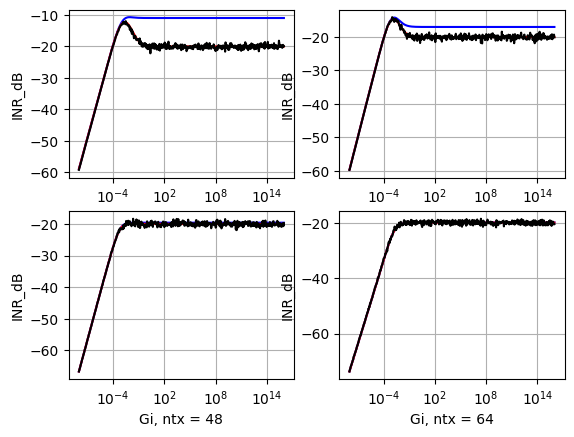

In [26]:
for n, ntx in enumerate(ntx_num):

    mean_G_i = np.mean(G_i[n,:,:], axis=0)
    mean_INR_theory_correct = 10*np.log10(np.mean(INR_theory_correct[n,:,:], axis=0))
    mean_INR_theory_incorrect = 10*np.log10(np.mean(INR_theory_incorrect[n,:,:], axis=0))
    mean_INR_pow = 10*np.log10(np.mean(INR_pow[n,:,:], axis=0))
    mean_INR0_pow = 10*np.log10(np.mean(INR0_pow[n,:,:], axis=0))
    mean_INR2_pow = 10*np.log10(np.mean(INR2_pow[n,:,:], axis=0))
    mean_INR3_pow = 10*np.log10(np.mean(INR3_pow[n,:,:], axis=0))
    mean_INR4_pow = 10*np.log10(np.mean(INR4_pow[n,:,:], axis=0))
    mean_INR = 10*np.log10(np.mean(inr[n,:,:], axis=0))
    mean_INR_new = 10*np.log10(np.mean(INR_new[n,:,:], axis=0))



    plt.subplot(2,2,n+1)
    plt.semilogx(mean_G_i, mean_INR_theory_correct, color='blue', label='INR_theory_correct')
    plt.semilogx(mean_G_i, mean_INR_theory_incorrect, color='red', label='INR_theory_incorrect')
    # plt.semilogx(mean_G_i, mean_INR_pow, color='green', label='INR_pow')
    plt.semilogx(mean_G_i, mean_INR, color='black', label='INR_pow')
    plt.xlabel(f'Gi, ntx = {ntx}')
    plt.ylabel('INR_dB')
    plt.grid()
plt.show()

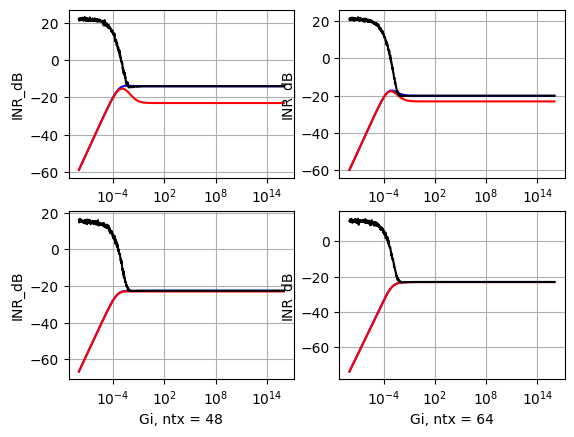

In [9]:
for n, ntx in enumerate(ntx_num):

    mean_G_i = np.mean(G_i[n,:,:], axis=0)
    mean_INR_theory_correct = 10*np.log10(np.mean(INR_theory_correct[n,:,:], axis=0))
    mean_INR_theory_incorrect = 10*np.log10(np.mean(INR_theory_incorrect[n,:,:], axis=0))
    mean_INR_pow = 10*np.log10(np.mean(INR_pow[n,:,:], axis=0))
    mean_INR0_pow = 10*np.log10(np.mean(INR0_pow[n,:,:], axis=0))
    mean_INR2_pow = 10*np.log10(np.mean(INR2_pow[n,:,:], axis=0))
    mean_INR3_pow = 10*np.log10(np.mean(INR3_pow[n,:,:], axis=0))
    mean_INR = 10*np.log10(np.mean(inr[n,:,:], axis=0))
    mean_INR_new = 10*np.log10(np.mean(INR_new[n,:,:], axis=0))



    plt.subplot(2,2,n+1)
    plt.semilogx(mean_G_i, mean_INR_theory_correct, color='blue', label='INR_theory_correct')
    plt.semilogx(mean_G_i, mean_INR_theory_incorrect, color='red', label='INR_theory_incorrect')
    # plt.semilogx(mean_G_i, mean_INR_pow, color='green', label='INR_pow')
    plt.semilogx(mean_G_i, mean_INR3_pow, color='black', label='INR_pow')
    plt.xlabel(f'Gi, ntx = {ntx}')
    plt.ylabel('INR_dB')
    plt.grid()
plt.show()

In [ ]:
for n, ntx in enumerate(ntx_num):

    mean_G_i = np.mean(G_i[n,:,:], axis=0)
    mean_INR_theory_correct = 10*np.log10(np.mean(INR_theory_correct[n,:,:], axis=0))
    mean_INR_theory_incorrect = 10*np.log10(np.mean(INR_theory_incorrect[n,:,:], axis=0))
    mean_INR_pow = 10*np.log10(np.mean(INR_pow[n,:,:], axis=0))
    mean_INR = 10*np.log10(np.mean(inr[n,:,:], axis=0))



    plt.subplot(2,3,n+1)
    plt.semilogx(mean_G_i, mean_INR, color='blue', label='mean_INR')
    plt.semilogx(mean_G_i, mean_INR_theory_incorrect, color='red', label='INR_theory_incorrect')
    # plt.semilogx(mean_G_i, mean_INR_pow, color='green', label='INR_pow')
    #plt.semilogx(mean_G_i, mean_INR, color='black', label='INR_pow')
    plt.xlabel(f'Gi, ntx = {ntx}')
    plt.ylabel('INR_dB')
    plt.grid()
plt.show()

In [ ]:
for n, ntx in enumerate(ntx_num):

    mean_G_i = np.mean(G_i[n,:,:], axis=0)
    mean_rho_hat_list= 10*np.log10(np.mean(rho_hat_list[n,:,:], axis=0))
    mean_rho_nom_abs2_list = 10*np.log10(np.mean(rho_nom_abs2_list[n,:,:], axis=0))



    plt.subplot(2,3,n+1)
    plt.semilogx(mean_G_i, mean_rho_hat_list, color='blue', label='Original h1 pow')
    plt.semilogx(mean_G_i, mean_rho_nom_abs2_list, color='red', label='Equalized h1 pow')
    plt.xlabel(f'Gi, ntx = {ntx}')
    plt.ylabel('rho_nom_abs2 in dB ')
    plt.grid()
plt.show()